In [44]:
import numpy as np
import cv2
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline 

In [46]:
img=cv2.imread('./test_images/che.jpeg')
img.shape

(255, 198, 3)

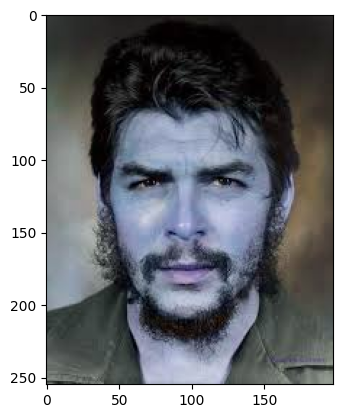

In [47]:
plt.imshow(img)

In [53]:
img=cv2.imread('./test_images/che.jpeg')
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)
eye_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_eye.xml"
)
faces = face_cascade.detectMultiScale(img, 1.3, 5)
faces

array([[ 27,  65, 138, 138]], dtype=int32)

In [54]:
(x,y,w,h) = faces[0]
x,y,w,h

(np.int32(27), np.int32(65), np.int32(138), np.int32(138))

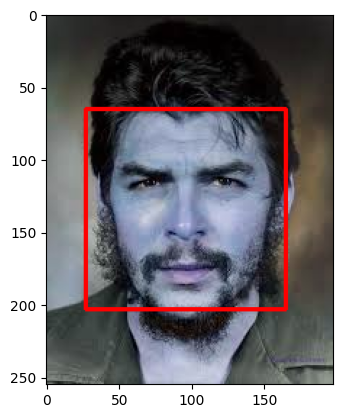

In [55]:
face_img = cv2.rectangle(img,(x,y),(x+w,y+h),(255,0,0),2)
plt.imshow(face_img)

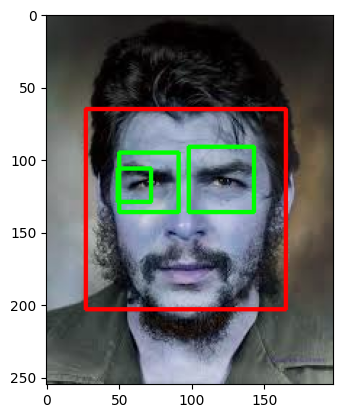

In [56]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
cv2.destroyAllWindows()
for (x,y,w,h) in faces:
    face_img = cv2.rectangle(img,(x,y),(x+w,y+h),(255,0,0),2)
    roi_gray = gray[y:y+h, x:x+w]
    roi_color = face_img[y:y+h, x:x+w]
    eyes = eye_cascade.detectMultiScale(roi_gray)
    for (ex,ey,ew,eh) in eyes:
        cv2.rectangle(roi_color,(ex,ey),(ex+ew,ey+eh),(0,255,0),2)
        

plt.figure()
plt.imshow(face_img, cmap='gray')
plt.show()

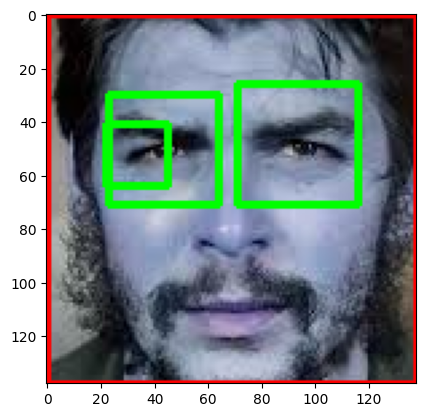

In [57]:
%matplotlib inline
plt.imshow(roi_color, cmap='gray')

In [95]:
def get_cropped_image_if_2_eyes(image_path):
    img = cv2.imread(image_path)
    
    if img is None:
        print(f"Skipping invalid file: {image_path}")
        return None
        
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.1, 4)
    
    for (x, y, w, h) in faces:
        roi_gray = gray[y:y+h, x:x+w]
        roi_color = img[y:y+h, x:x+w]
        eyes = eye_cascade.detectMultiScale(roi_gray, 1.1, 2)
        
        if len(eyes) >= 2:
            return roi_color
            
    return None

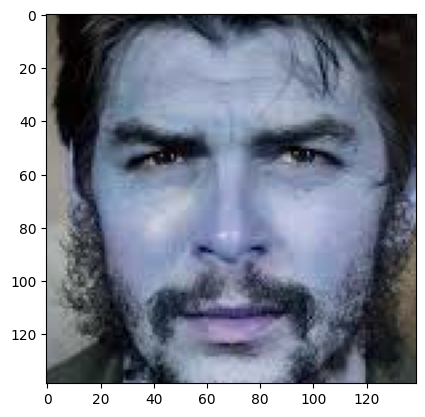

In [96]:
cropped_image = get_cropped_image_if_2_eyes('./test_images/che.jpeg')
plt.imshow(cropped_image)

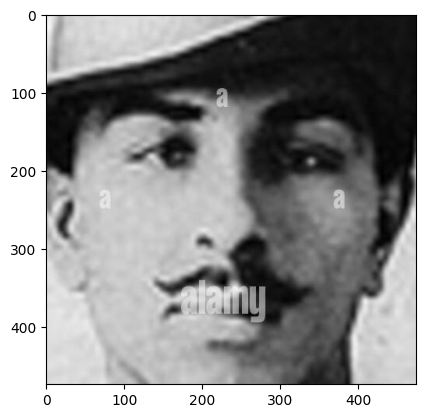

In [97]:
cropped_image = get_cropped_image_if_2_eyes('./test_images/bhagat.jpg')
plt.imshow(cropped_image)

In [98]:
path_to_data = "./model/dataset/"
path_to_cr_data = "./model/dataset/cropped/"

In [99]:
import os
img_dirs = []
for entry in os.scandir(path_to_data):
    if entry.is_dir():
        img_dirs.append(entry.path)
img_dirs

['./model/dataset/FIDEL CASTRO',
 './model/dataset/XI JINPING',
 './model/dataset/BHAGAT',
 './model/dataset/CHE GUEVARA',
 './model/dataset/.ipynb_checkpoints',
 './model/dataset/cropped',
 './model/dataset/LENIN']

In [100]:
import shutil
if os.path.exists(path_to_cr_data):
     shutil.rmtree(path_to_cr_data)
os.mkdir(path_to_cr_data)

In [101]:
cropped_image_dirs = []
file_names_dict = {}

for img_dir in img_dirs:
    count = 1
    name = img_dir.split('/')[-1]
    print(name)
    
    file_names_dict[name] = []
    
    for entry in os.scandir(img_dir):
        roi_color = get_cropped_image_if_2_eyes(entry.path)
        if roi_color is not None:
            cropped_folder = path_to_cr_data +name
            if not os.path.exists(cropped_folder):
                os.makedirs(cropped_folder)
                cropped_image_dirs.append(cropped_folder)
                print("Generating cropped images in folder: ",cropped_folder)
                
            cropped_file_name = name + str(count) + ".png"
            cropped_file_path = cropped_folder + "/" + cropped_file_name 
            
            cv2.imwrite(cropped_file_path, roi_color)
            file_names_dict[name].append(cropped_file_path)
            count += 1    

FIDEL CASTRO
Generating cropped images in folder:  ./model/dataset/cropped/FIDEL CASTRO
XI JINPING
Generating cropped images in folder:  ./model/dataset/cropped/XI JINPING
BHAGAT
Generating cropped images in folder:  ./model/dataset/cropped/BHAGAT
Skipping invalid file: ./model/dataset/BHAGAT/.DS_Store
CHE GUEVARA
Generating cropped images in folder:  ./model/dataset/cropped/CHE GUEVARA
.ipynb_checkpoints
cropped
Skipping invalid file: ./model/dataset/cropped/FIDEL CASTRO
Skipping invalid file: ./model/dataset/cropped/XI JINPING
Skipping invalid file: ./model/dataset/cropped/BHAGAT
Skipping invalid file: ./model/dataset/cropped/CHE GUEVARA
LENIN
Generating cropped images in folder:  ./model/dataset/cropped/LENIN
